# DDPM with Unet Architecture applied to FashionMNIST Dataset

In [1]:
#!git clone https://github.com/Jackson-Kang/Pytorch-Diffusion-Model-Tutorial.git
#%cd Pytorch-Diffusion-Model-Tutorial
!pip install -r requirements.txt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
np.Inf = np.inf

from tqdm import tqdm
from torchvision.utils import save_image, make_grid
from tqdm import tqdm
from torch.optim import Adam

import math

In [3]:
# Model Hyperparameters

dataset_path = '~/datasets'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

dataset = 'FashionMNIST'
img_size = (32, 32, 3)   if dataset == "CIFAR10" else (28, 28, 1) # (width, height, channels)

timestep_embedding_dim = 256
n_layers = 8
hidden_dim = 256
n_timesteps = 1000
beta_minmax=[1e-4, 2e-2]

train_batch_size = 128
inference_batch_size = 64
lr = 5e-5
epochs = 200

seed = 1234

hidden_dims = [hidden_dim for _ in range(n_layers)]
torch.manual_seed(seed)
np.random.seed(seed)

Using device: mps


## Step 1. Load (or download) Dataset

In [4]:
from torchvision.datasets import MNIST, CIFAR10, FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
        transforms.ToTensor(),
])

kwargs = {'num_workers': 4, 'pin_memory': True}

if dataset == 'CIFAR10':
    train_dataset = CIFAR10(dataset_path, transform=transform, train=True, download=True)
    test_dataset  = CIFAR10(dataset_path, transform=transform, train=False, download=True)
elif dataset == 'FashionMNIST':
    train_dataset = FashionMNIST(dataset_path, transform=transform, train=True, download=True)
    test_dataset  = FashionMNIST(dataset_path, transform=transform, train=False, download=True)
else:
    train_dataset = MNIST(dataset_path, transform=transform, train=True, download=True)
    test_dataset  = MNIST(dataset_path, transform=transform, train=False, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=train_batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=inference_batch_size, shuffle=False,  **kwargs)

## Step 2. Define model: Denoising Diffusion Probabilistic Models (DDPMs)

Sinusoidal embedding for diffusion timestep

In [5]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb) #128 frequencies that shrink exponentially
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [6]:

# Original custom DoubleConv + UNet (kept here for reference, commented out)

# class DoubleConv(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.double_conv = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
#             nn.GroupNorm(8, out_channels),
#             nn.SiLU(),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
#             nn.GroupNorm(8, out_channels),
#             nn.SiLU()
#         )
#
#     def forward(self, x):
#         return self.double_conv(x)
#
# class UNet(nn.Module):
#     def __init__(self, image_resolution, hidden_dims=[64, 128, 256], diffusion_time_embedding_dim=256, n_times=1000):
#         super(UNet, self).__init__()
#         _, _, img_C = image_resolution
#
#         self.time_embedding = SinusoidalPosEmb(diffusion_time_embedding_dim)
#         self.time_project = nn.Sequential(
#             nn.Linear(diffusion_time_embedding_dim, hidden_dims[0]),
#             nn.SiLU(),
#             nn.Linear(hidden_dims[0], hidden_dims[0])
#         )
#
#         # Encoder (downsampling)
#         self.inc = DoubleConv(img_C, hidden_dims[0])                                              # 1 -> 64
#         self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(hidden_dims[0], hidden_dims[1]))   # 64 -> 128
#         self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(hidden_dims[1], hidden_dims[2]))   # 128 -> 256
#
#         # Decoder (upsampling)
#         self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#         self.conv_up1 = DoubleConv(hidden_dims[2] + hidden_dims[1], hidden_dims[1])               # 256+128 -> 128
#
#         self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#         self.conv_up2 = DoubleConv(hidden_dims[1] + hidden_dims[0], hidden_dims[0])               # 128+64 -> 64
#
#         self.outc = nn.Conv2d(hidden_dims[0], img_C, kernel_size=1)                               # 64 -> 1
#
#     def forward(self, x, diffusion_timestep):
#         t_emb = self.time_embedding(diffusion_timestep)
#         t_emb = self.time_project(t_emb).unsqueeze(-1).unsqueeze(-2)
#
#         x1 = self.inc(x)
#         x1 = x1 + t_emb
#         x2 = self.down1(x1)
#         x3 = self.down2(x2)
#
#         x = self.up1(x3)
#         x = torch.cat([x, x2], dim=1)
#         x = self.conv_up1(x)
#         x = self.up2(x)
#         x = torch.cat([x, x1], dim=1)
#         x = self.conv_up2(x)
#
#         out = self.outc(x)
#         return out
#
# model = UNet(image_resolution=img_size,
#              hidden_dims=[64, 128, 256],
#              diffusion_time_embedding_dim=timestep_embedding_dim,
#              n_times=n_timesteps).to(DEVICE)


# New denoiser: UNet from lucidrains' denoising-diffusion-pytorch
#   pip install denoising-diffusion-pytorch
#
# Architectural differences vs. the custom UNet above:
#   - ResNet blocks (with residual skips) instead of plain DoubleConv
#   - Time embedding (sinusoidal + MLP) injected via FiLM into EVERY ResBlock
#   - Linear attention at every resolution + full attention at the bottleneck
#   - Space-to-depth downsampling and nearest-neighbour upsampling
#
# For 28x28 FashionMNIST we use 3 resolution levels (28 -> 14 -> 7).

from denoising_diffusion_pytorch import Unet

model = Unet(
    dim=32,                  # base channel count
    dim_mults=(1, 2, 4),     # 3 levels: 28x28 -> 14x14 -> 7x7  (channels 32/64/128)
    channels=1,              # grayscale FashionMNIST
    flash_attn=False,        # set True only if flash-attn is installed
).to(DEVICE)


### Define Gaussian Diffusion

In [7]:
class Diffusion(nn.Module):
    def __init__(self, model, image_resolution=[32, 32, 3], n_times=1000, beta_minmax=[1e-4, 2e-2], device=DEVICE):

        super(Diffusion, self).__init__()

        self.n_times = n_times
        self.img_H, self.img_W, self.img_C = image_resolution

        self.model = model

        # define linear variance schedule(betas)
        beta_1, beta_T = beta_minmax
        betas = torch.linspace(start=beta_1, end=beta_T, steps=n_times).to(device) # early timesteps have small variance, later timesteps have large variance
        self.sqrt_betas = torch.sqrt(betas)

        # define alpha for forward diffusion kernel
        self.alphas = 1 - betas
        self.sqrt_alphas = torch.sqrt(self.alphas)
        alpha_bars = torch.cumprod(self.alphas, dim=0) #total signal retention
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1-alpha_bars)
        self.sqrt_alpha_bars = torch.sqrt(alpha_bars)

        self.device = device

    def extract(self, a, t, x_shape):
        """
            from lucidrains' implementation
                https://github.com/lucidrains/denoising-diffusion-pytorch/blob/beb2f2d8dd9b4f2bd5be4719f37082fe061ee450/denoising_diffusion_pytorch/denoising_diffusion_pytorch.py#L376
        """
        b, *_ = t.shape
        out = a.gather(-1, t)
        return out.reshape(b, *((1,) * (len(x_shape) - 1)))

    def scale_to_minus_one_to_one(self, x):
        # according to the DDPMs paper, normalization seems to be crucial to train reverse process network
        return x * 2 - 1

    def reverse_scale_to_zero_to_one(self, x):
        return (x + 1) * 0.5

    def make_noisy(self, x_zeros, t):
        # perturb x_0 into x_t (i.e., take x_0 samples into forward diffusion kernels)
        epsilon = torch.randn_like(x_zeros).to(self.device)

        sqrt_alpha_bar = self.extract(self.sqrt_alpha_bars, t, x_zeros.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alpha_bars, t, x_zeros.shape)

        # Forward process with fixed variance schedule (linear beta schedule)
        # x_t = sqrt(alpha_bar_t) * x_zero + sqrt(1-alpha_bar_t) * epsilon
        noisy_sample = x_zeros * sqrt_alpha_bar + epsilon * sqrt_one_minus_alpha_bar #closed form solution for forward process
    

        return noisy_sample.detach(), epsilon


    def forward(self, x_zeros):
        x_zeros = self.scale_to_minus_one_to_one(x_zeros) #normalize to be centered around zero (same as noise distribution)

        B, _, _, _ = x_zeros.shape #extract batch size

        # (1) randomly choose diffusion time-step
        t = torch.randint(low=0, high=self.n_times, size=(B,)).long().to(self.device)

        # (2) forward diffusion process: perturb x_zeros with fixed variance schedule
        perturbed_images, epsilon = self.make_noisy(x_zeros, t)

        # (3) predict epsilon(noise) given perturbed data at diffusion-timestep t.
        pred_epsilon = self.model(perturbed_images, t)

        return perturbed_images, epsilon, pred_epsilon


    def denoise_at_t(self, x_t, timestep, t):
        # takes noisy image at time t, and predict less noisy image at time t-1
        # new noise z is added for stochasticity
        B, _, _, _ = x_t.shape
        if t > 1:
            z = torch.randn_like(x_t).to(self.device)
        else:
            z = torch.zeros_like(x_t).to(self.device)

        # at inference, we use predicted noise(epsilon) to restore perturbed data sample.
        epsilon_pred = self.model(x_t, timestep)

        alpha = self.extract(self.alphas, timestep, x_t.shape)
        sqrt_alpha = self.extract(self.sqrt_alphas, timestep, x_t.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alpha_bars, timestep, x_t.shape)
        sqrt_beta = self.extract(self.sqrt_betas, timestep, x_t.shape)

        # denoise at time t, utilizing predicted noise
        x_t_minus_1 = 1 / sqrt_alpha * (x_t - (1-alpha)/sqrt_one_minus_alpha_bar*epsilon_pred) + sqrt_beta*z

        return x_t_minus_1.clamp(-1., 1)

    def sample(self, N):
        # start from random noise vector, generate image by iteratively denoising it
        # N is the number of samples to generate
        x_t = torch.randn((N, self.img_C, self.img_H, self.img_W)).to(self.device)

        # autoregressively denoise from x_t to x_0
        for t in range(self.n_times-1, -1, -1): #Iterates t = 999, 998, ..., 1, 0
            timestep = torch.tensor([t]).repeat_interleave(N, dim=0).long().to(self.device)
            x_t = self.denoise_at_t(x_t, timestep, t)

        # denormalize x_0 into [0,1] ranged values.
        x_0 = self.reverse_scale_to_zero_to_one(x_t)

        return x_0


diffusion = Diffusion(model, image_resolution=img_size, n_times=n_timesteps,
                      beta_minmax=beta_minmax, device=DEVICE).to(DEVICE)

optimizer = Adam(diffusion.parameters(), lr=lr)
denoising_loss = nn.MSELoss()

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of model parameters: ", count_parameters(diffusion))

Number of model parameters:  2607681


### Visualizing forward process

In [9]:
model.eval()
for batch_idx, (x, _) in enumerate(test_loader):
    x = x.to(DEVICE)
    perturbed_images, epsilon, pred_epsilon = diffusion(x)
    perturbed_images = diffusion.reverse_scale_to_zero_to_one(perturbed_images)
    break

In [10]:
def show_image(x, idx):
    fig = plt.figure()
    plt.imshow(x[idx].transpose(0, 1).transpose(1, 2).detach().cpu().numpy())

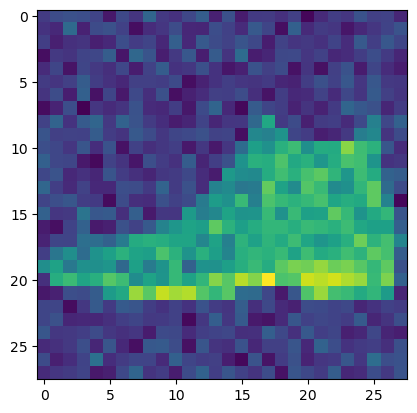

In [11]:
show_image(perturbed_images, idx=0)

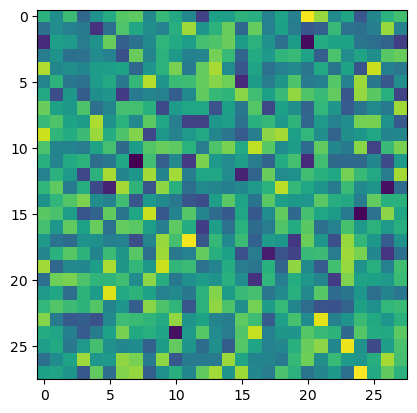

In [12]:
show_image(perturbed_images, idx=1)

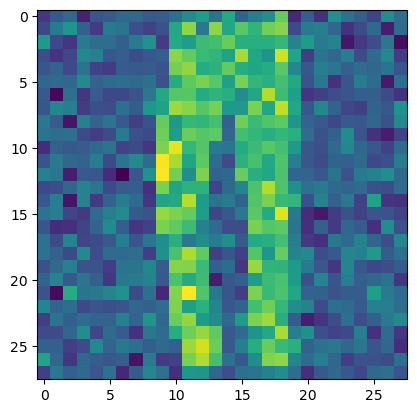

In [13]:
show_image(perturbed_images, idx=2)

## Step 3. Train Denoising Diffusion Probabilistic Models(DDPMs)

In [14]:

# print("Start training DDPMs...")
# model.train()

# for epoch in range(epochs):
#     noise_prediction_loss = 0
#     for batch_idx, (x, _) in tqdm(enumerate(train_loader), total=len(train_loader)):
#         optimizer.zero_grad()

#         x = x.to(DEVICE)

#         noisy_input, epsilon, pred_epsilon = diffusion(x)
#         loss = denoising_loss(pred_epsilon, epsilon)

#         noise_prediction_loss += loss.item()

#         loss.backward()
#         optimizer.step()

#     print("\tEpoch", epoch + 1, "complete!", "\tDenoising Loss: ", noise_prediction_loss / batch_idx)

# print("Finish!!")

In [32]:
import os

checkpoint_path = '/Users/vivienohlms/Documents/UvA/Period 5/Machine Learning/diffusion-models-project/vivien/models/vivien_lucidrains_unet_fashion_mnist/checkpoint_epoch_200.pt'
state_dict = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(state_dict)

print(f"Loaded checkpoint from {checkpoint_path}")

losses_path = os.path.join(os.path.dirname(checkpoint_path), 'losses.pt')
losses = torch.load(losses_path, map_location='cpu')
print(f"Last training loss: {losses['train'][-1]:.6f} (epoch {len(losses['train'])})")


/var/folders/v4/wh4l29gn14b9m0c46dzl2hjc0000gn/T/ipykernel_21872/732965948.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_l

Loaded checkpoint from /Users/vivienohlms/Documents/UvA/Period 5/Machine Learning/diffusion-models-project/vivien/models/vivien_lucidrains_unet_fashion_mnist/checkpoint_epoch_200.pt
Last training loss: 0.034234 (epoch 200)


## Step 4. Sample images from noise.

In [16]:
model.eval()

with torch.no_grad():
    generated_images = diffusion.sample(N=inference_batch_size)

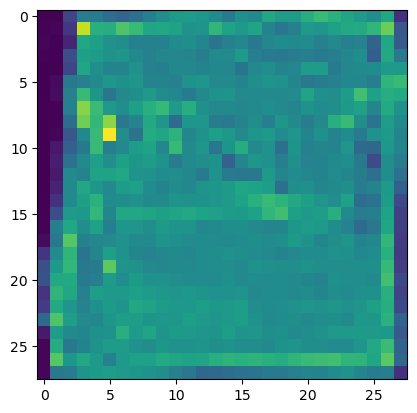

In [17]:
show_image(generated_images, idx=0)

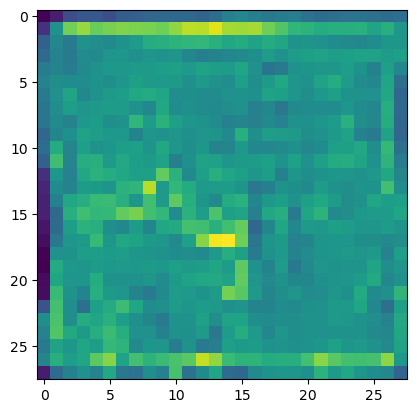

In [18]:
show_image(generated_images, idx=1)

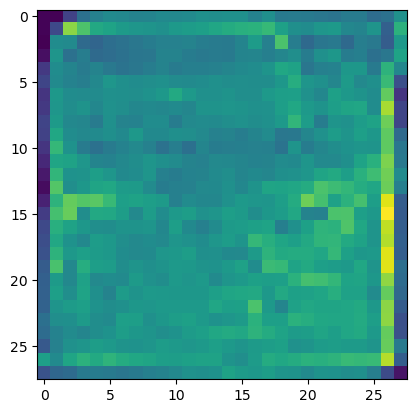

In [19]:
show_image(generated_images, idx=2)

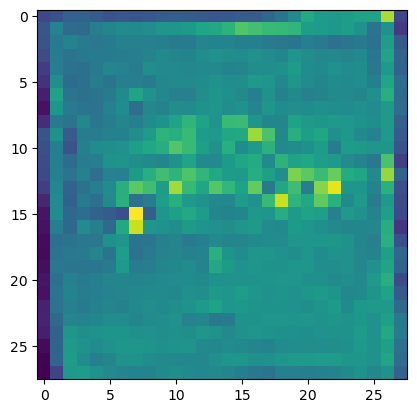

In [20]:
show_image(generated_images, idx=3)

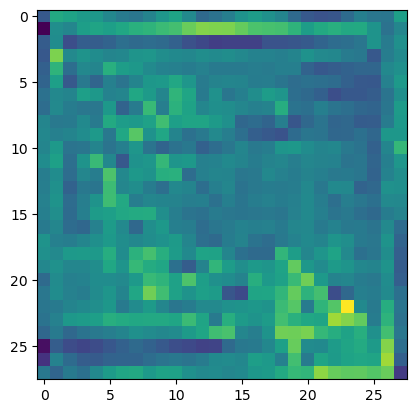

In [21]:
show_image(generated_images, idx=4)

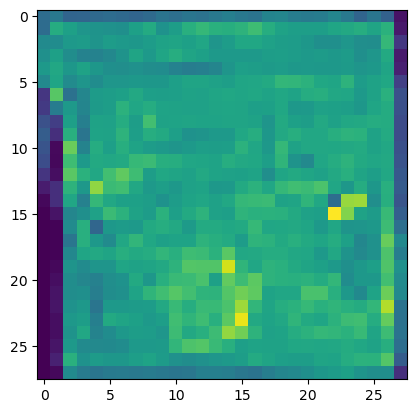

In [22]:
show_image(generated_images, idx=5)

### Comparison with ground-truth samples

In [23]:
def draw_sample_image(x, postfix):

    plt.axis("off")
    plt.title("Visualization of {}".format(postfix))
    plt.imshow(np.transpose(make_grid(x.detach().cpu(), padding=2, normalize=True), (1, 2, 0)))

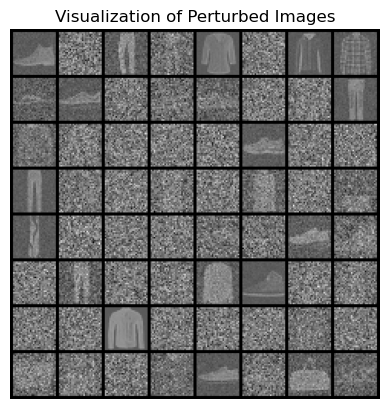

In [24]:
draw_sample_image(perturbed_images, "Perturbed Images")

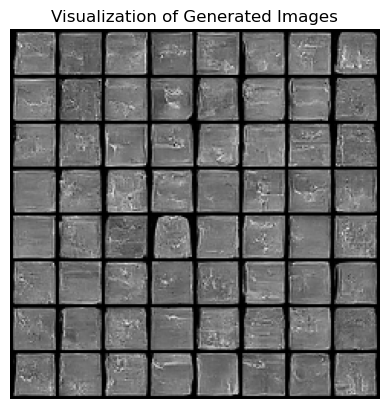

In [25]:
draw_sample_image(generated_images, "Generated Images")

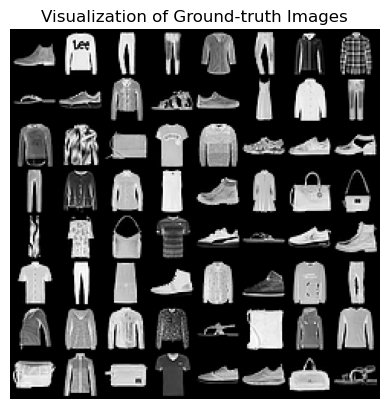

In [26]:
draw_sample_image(x[:inference_batch_size], "Ground-truth Images")